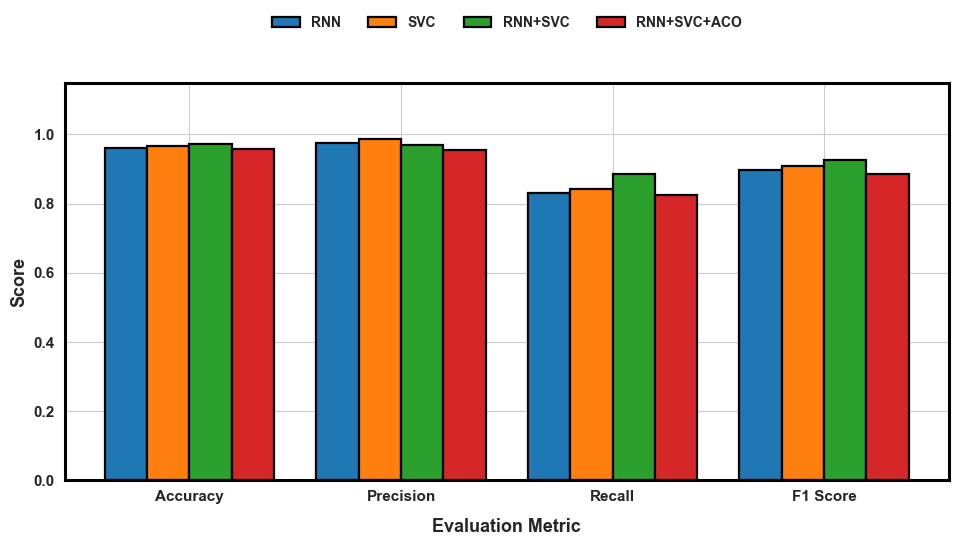

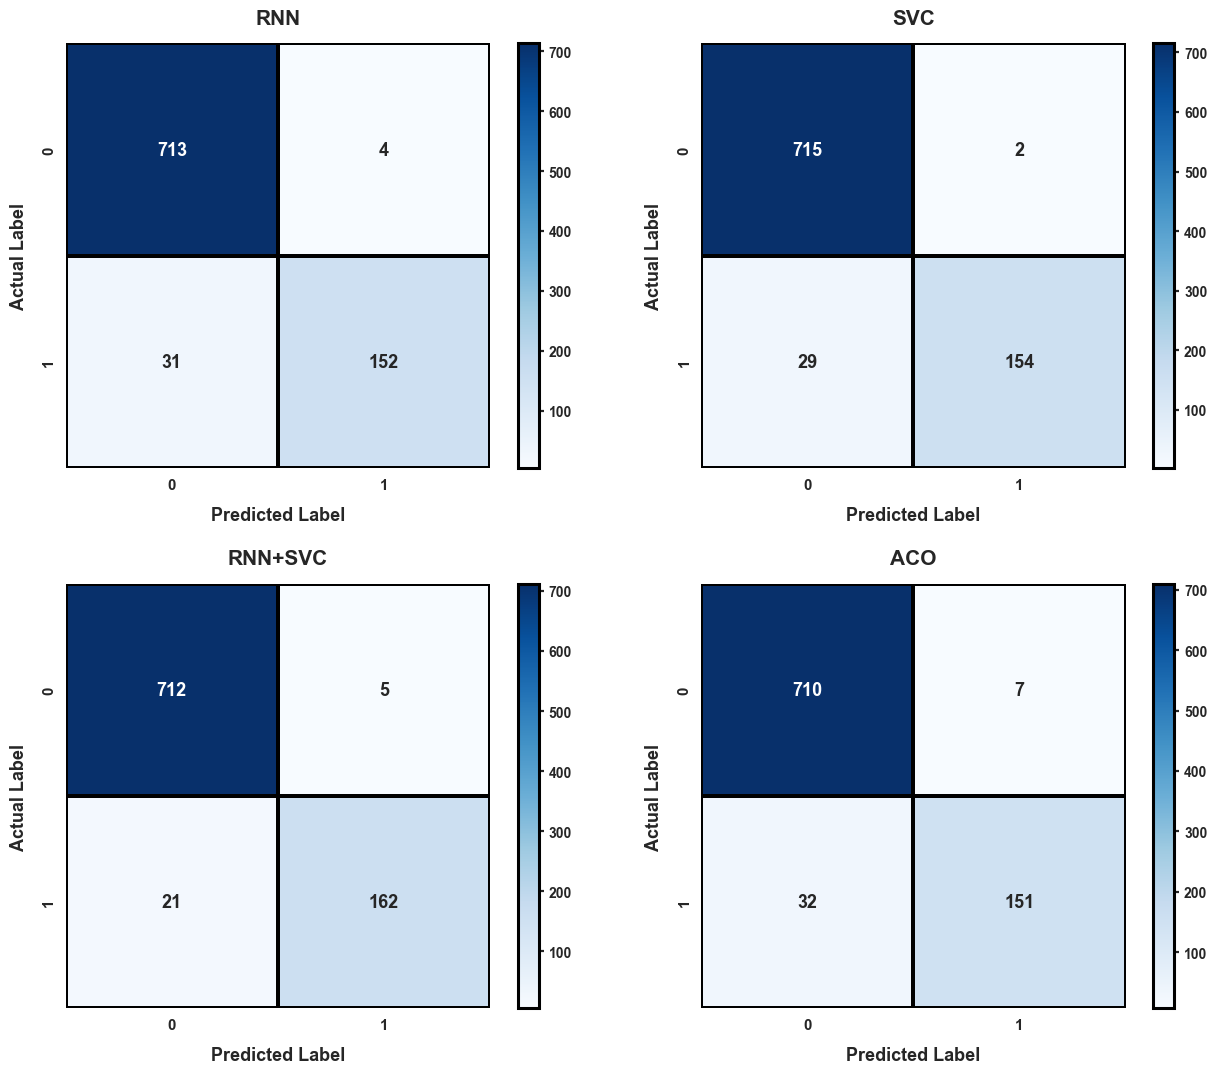

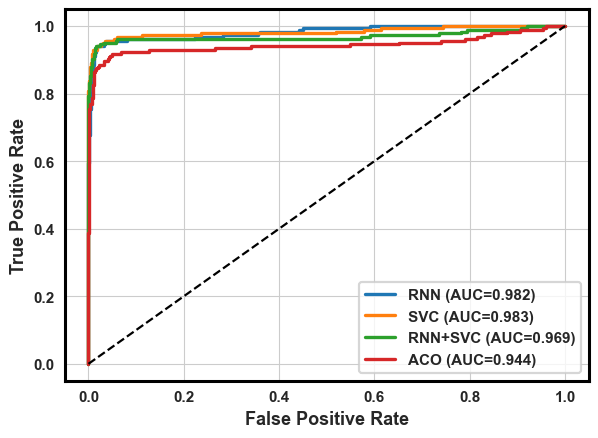

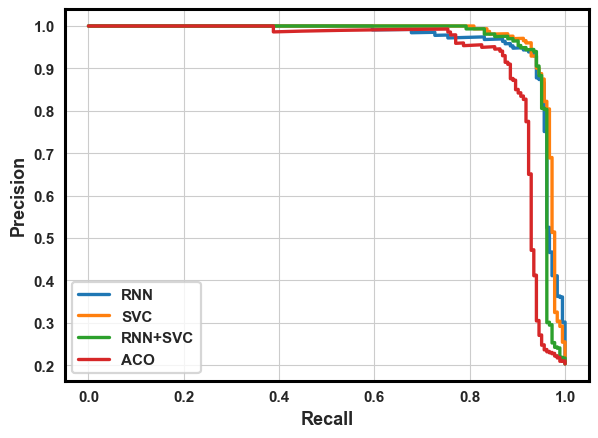

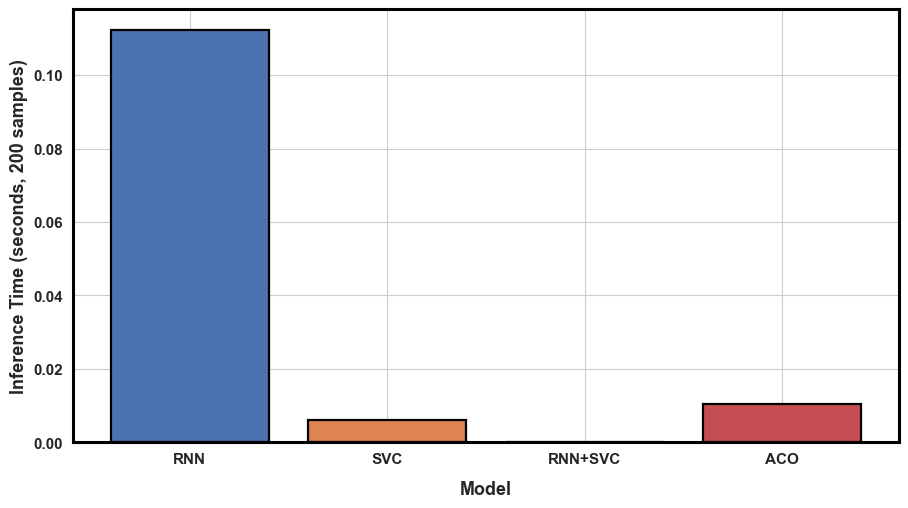

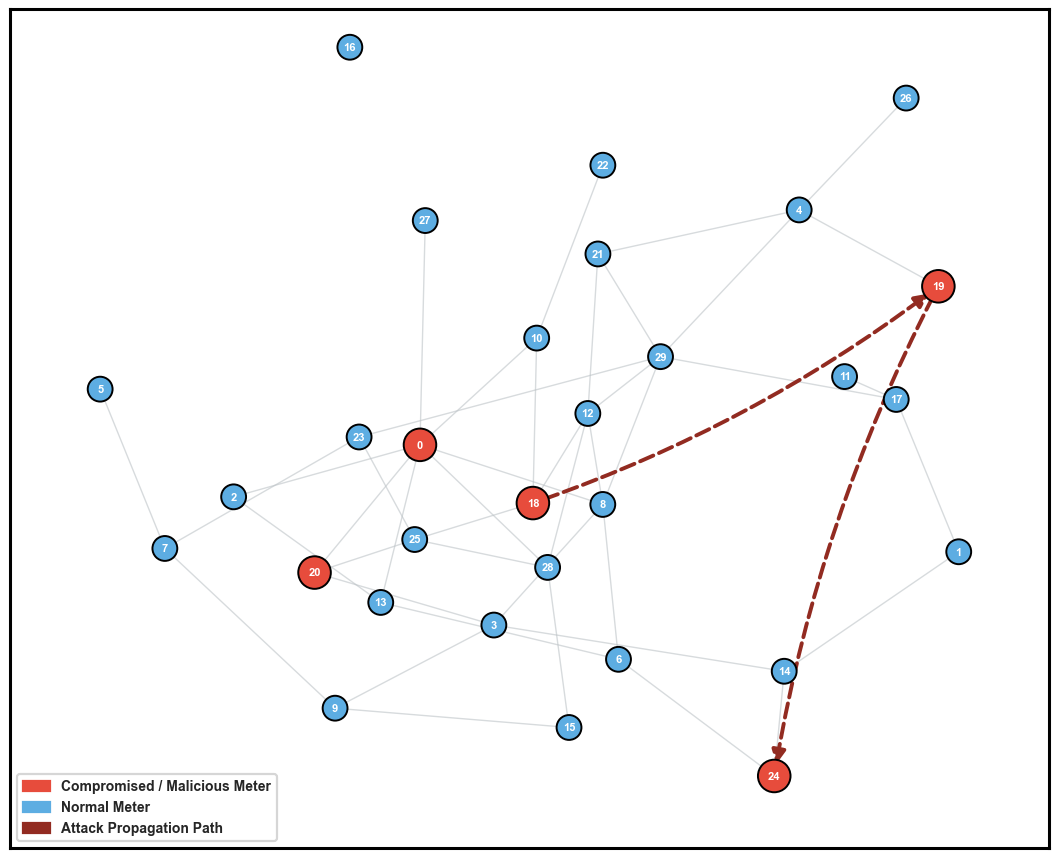

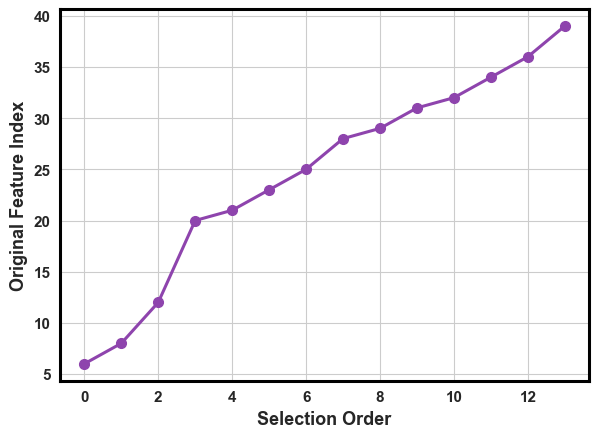

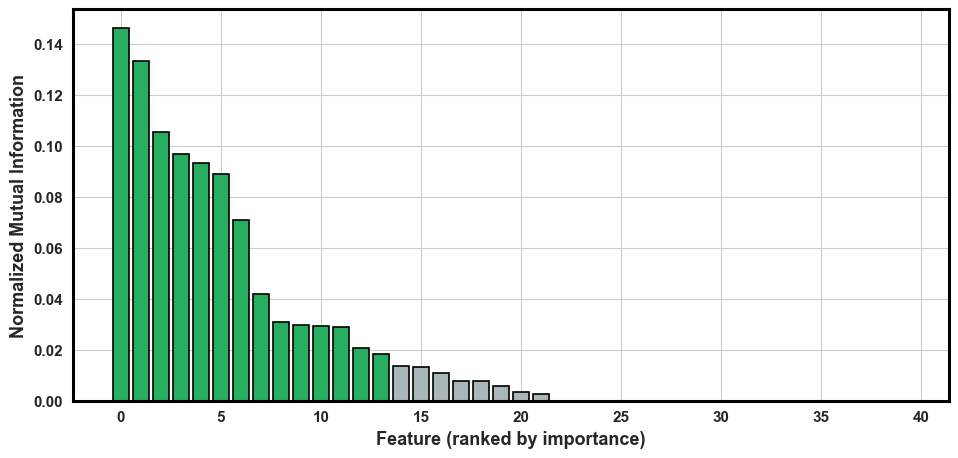

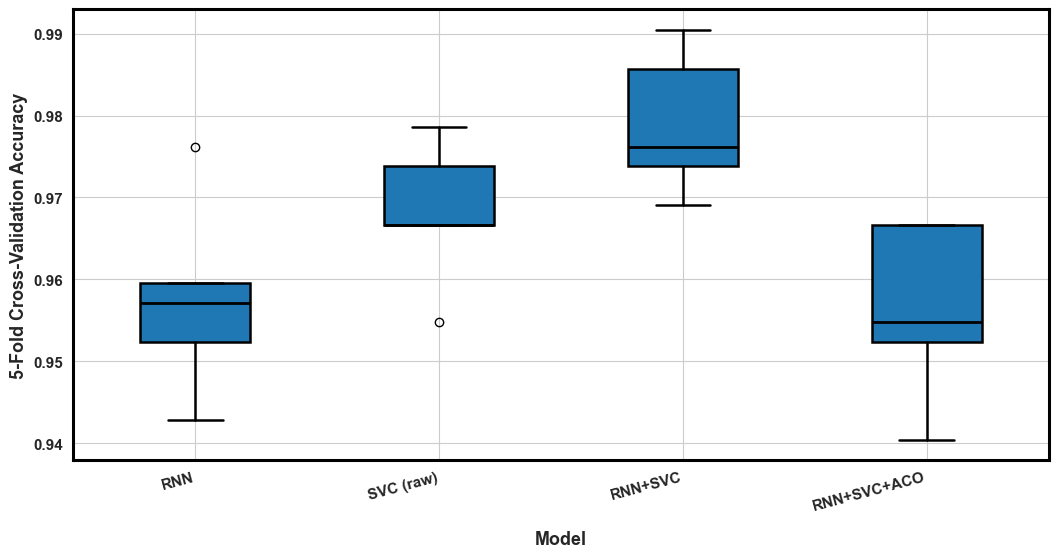

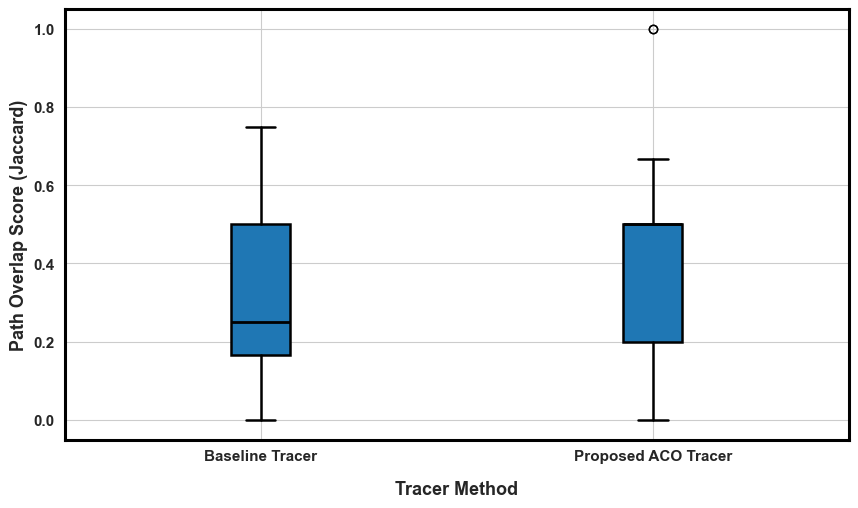

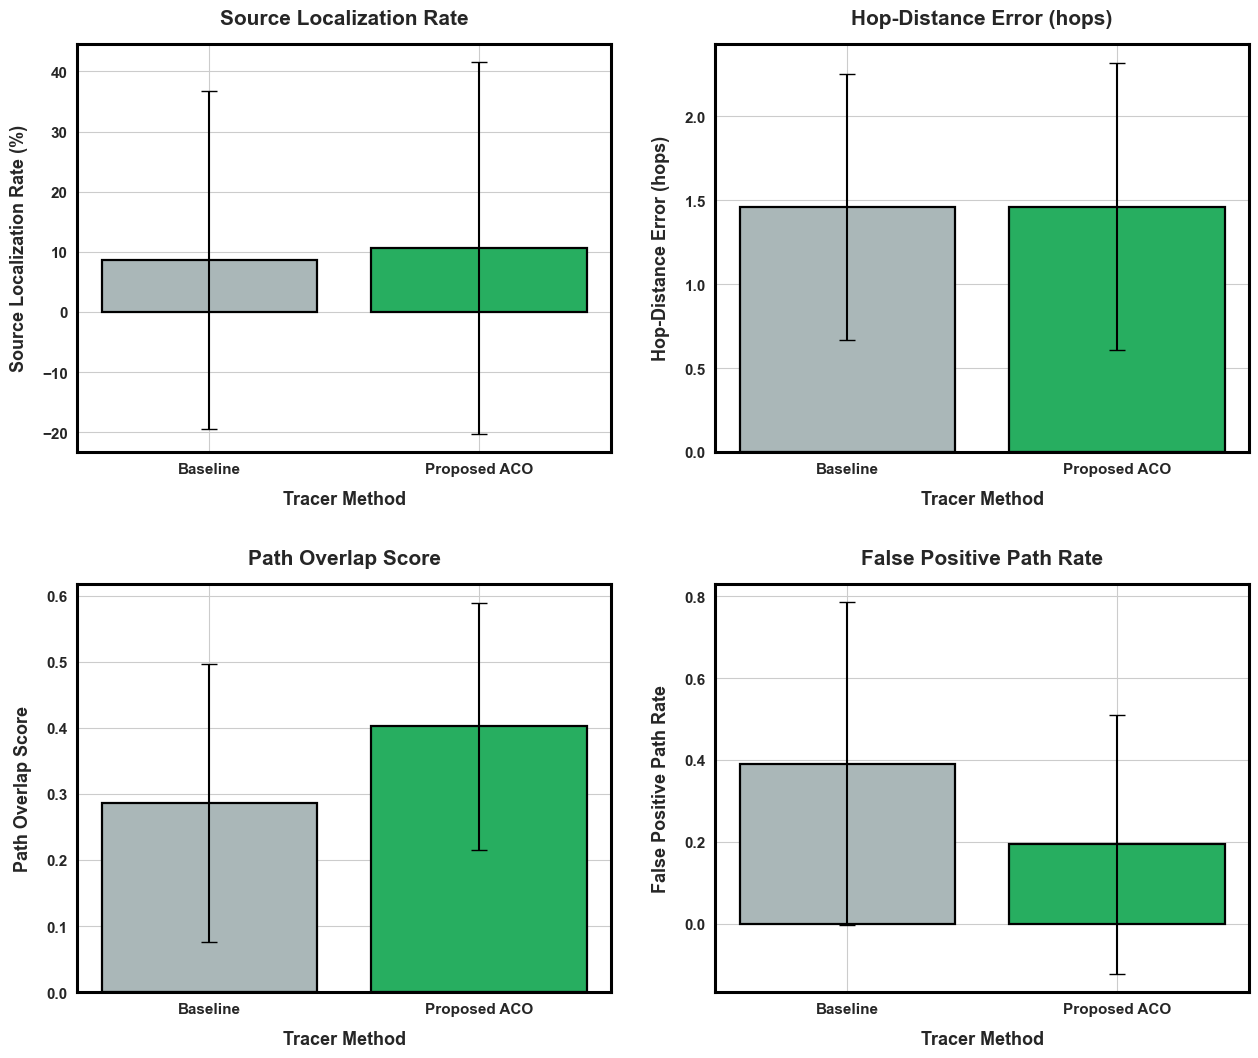

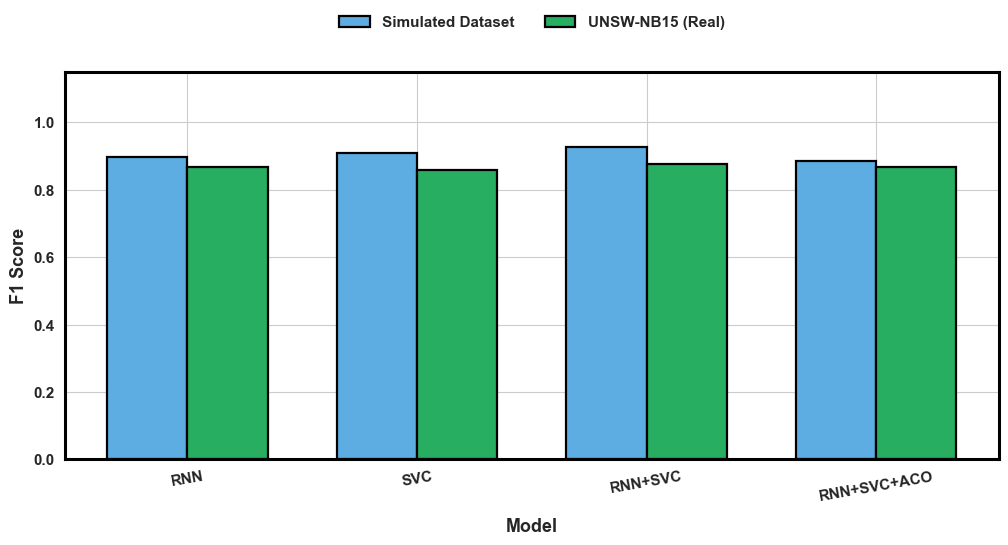


===== SIMPLE FEATURE COMPARISON TABLE =====
         Model Feature Type  Feature Count                    Meaning
0          RNN          Raw             40              Original data
1          SVC          Raw             40          No transformation
2      RNN+SVC      Learned             32  Compressed representation
3  RNN+SVC+ACO     Selected             14             Optimal subset


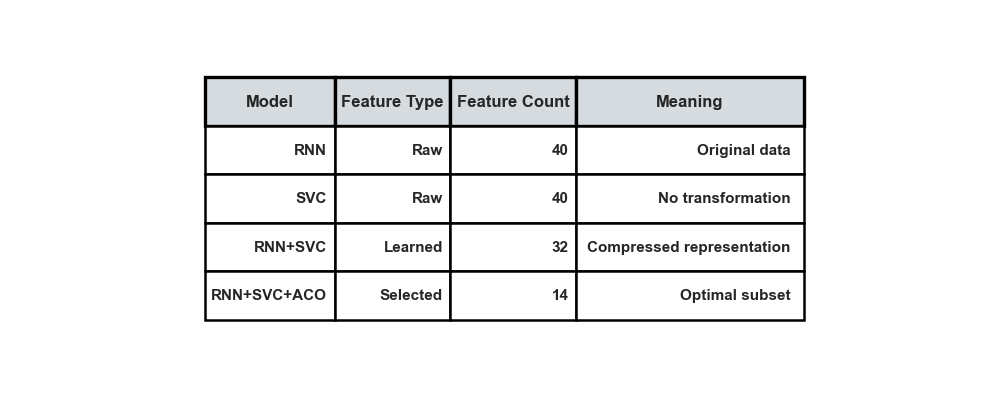

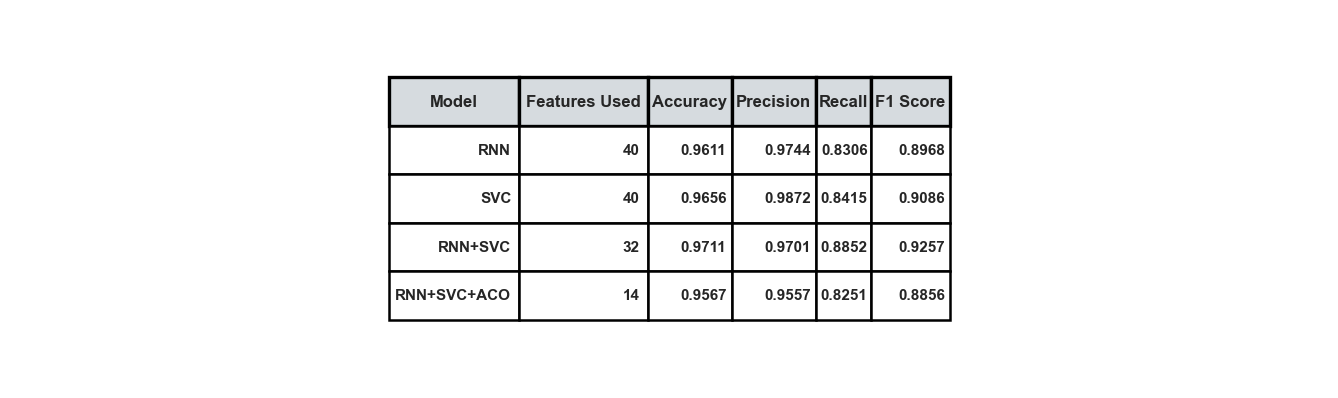

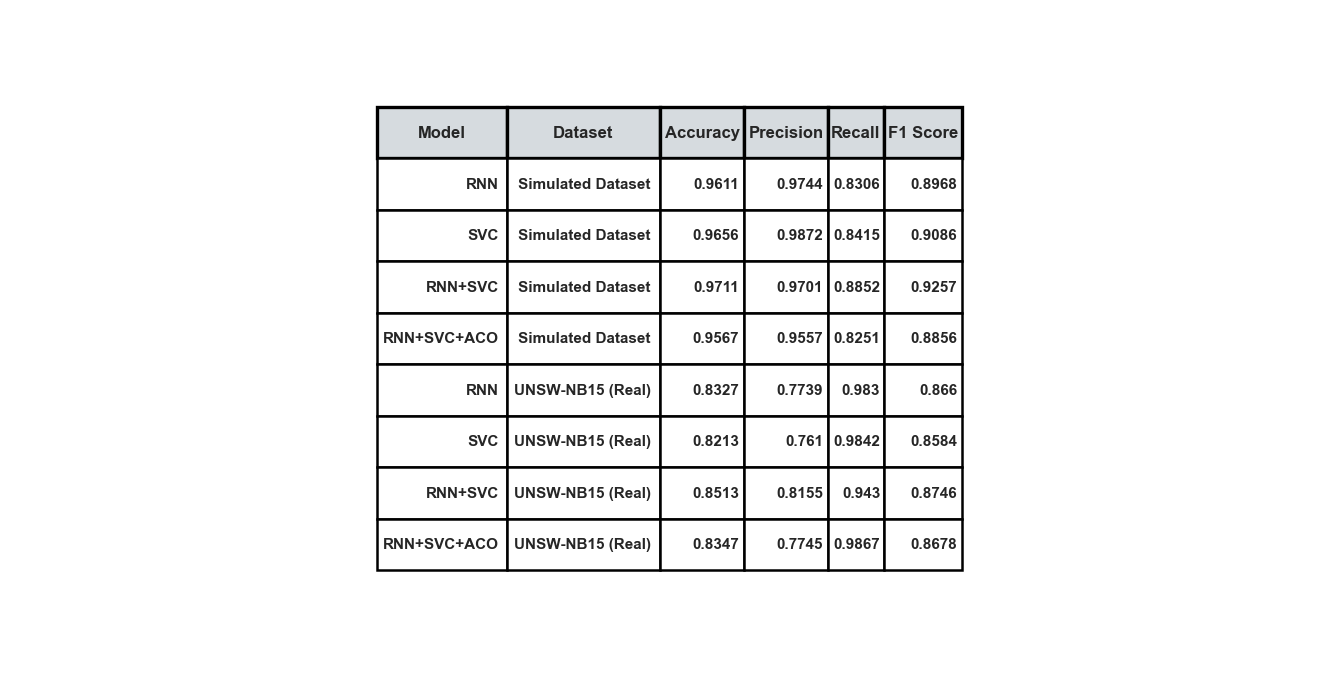

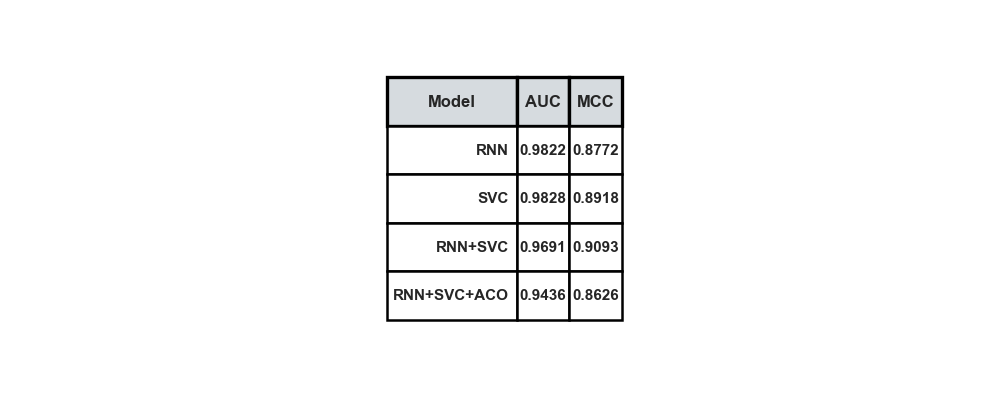

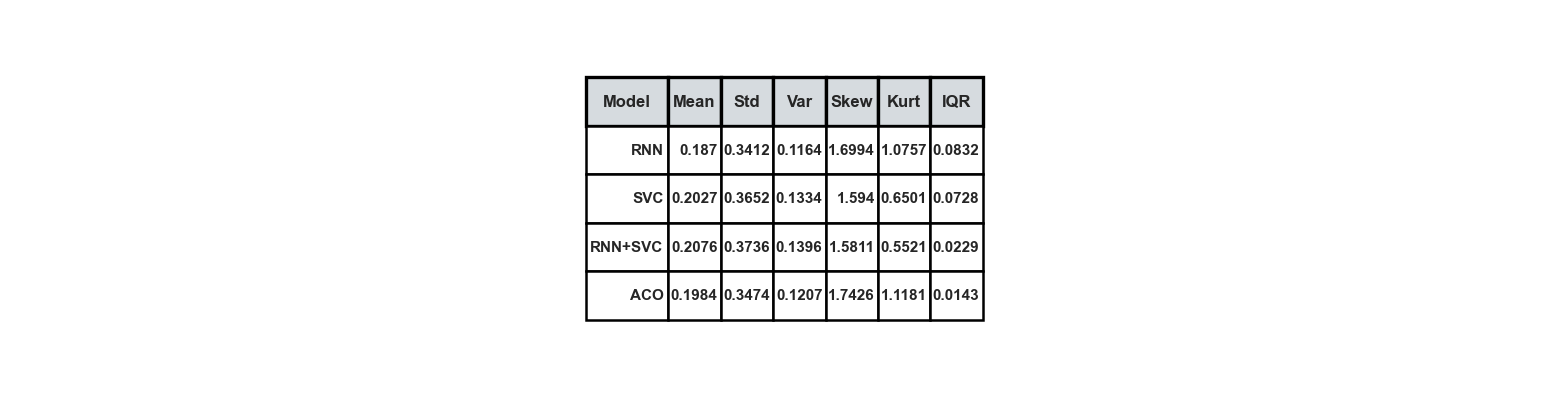

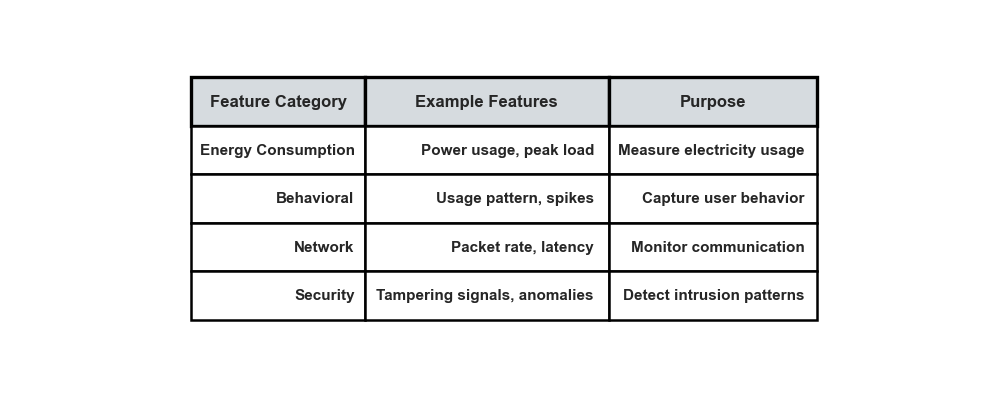

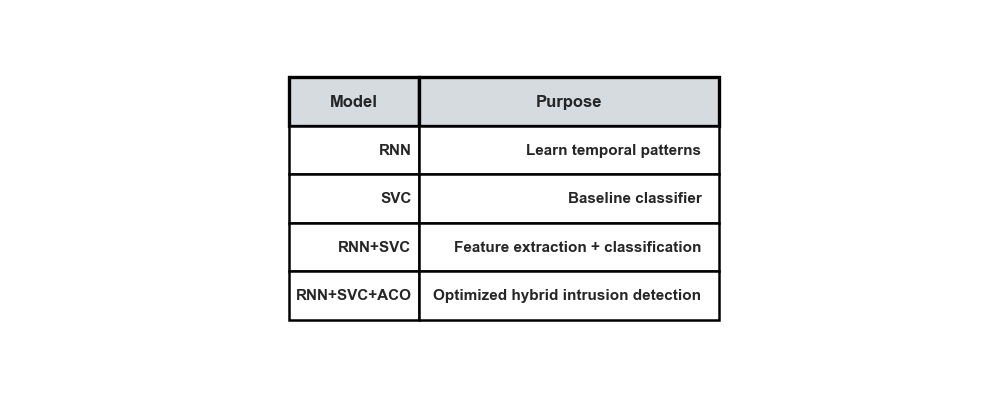

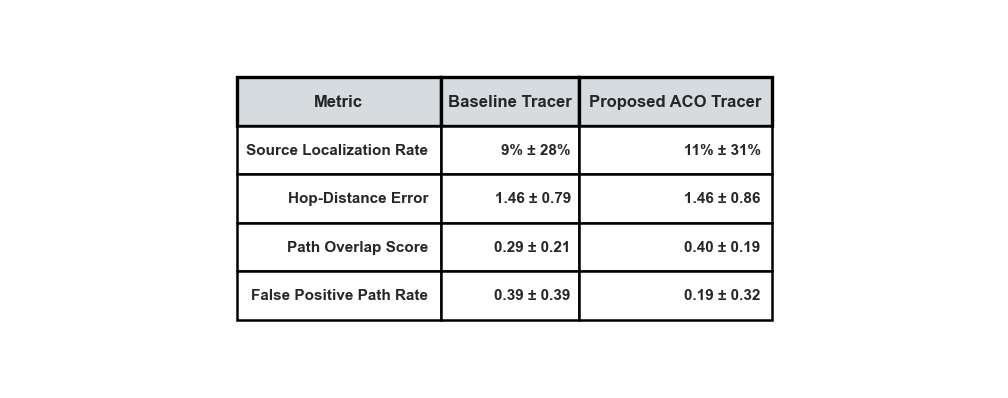

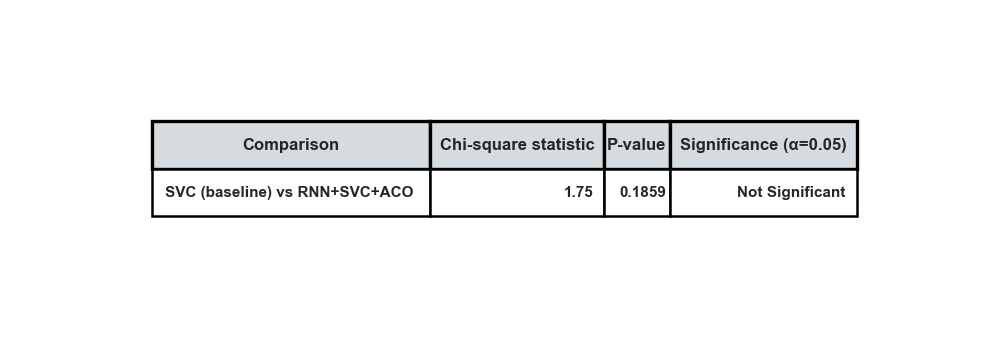

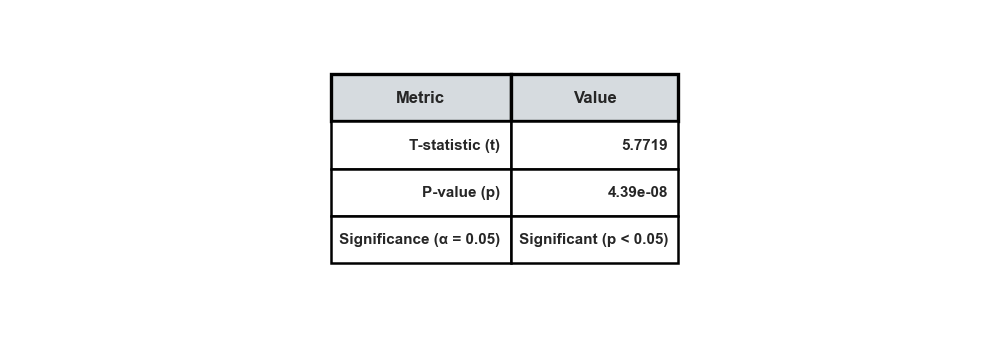

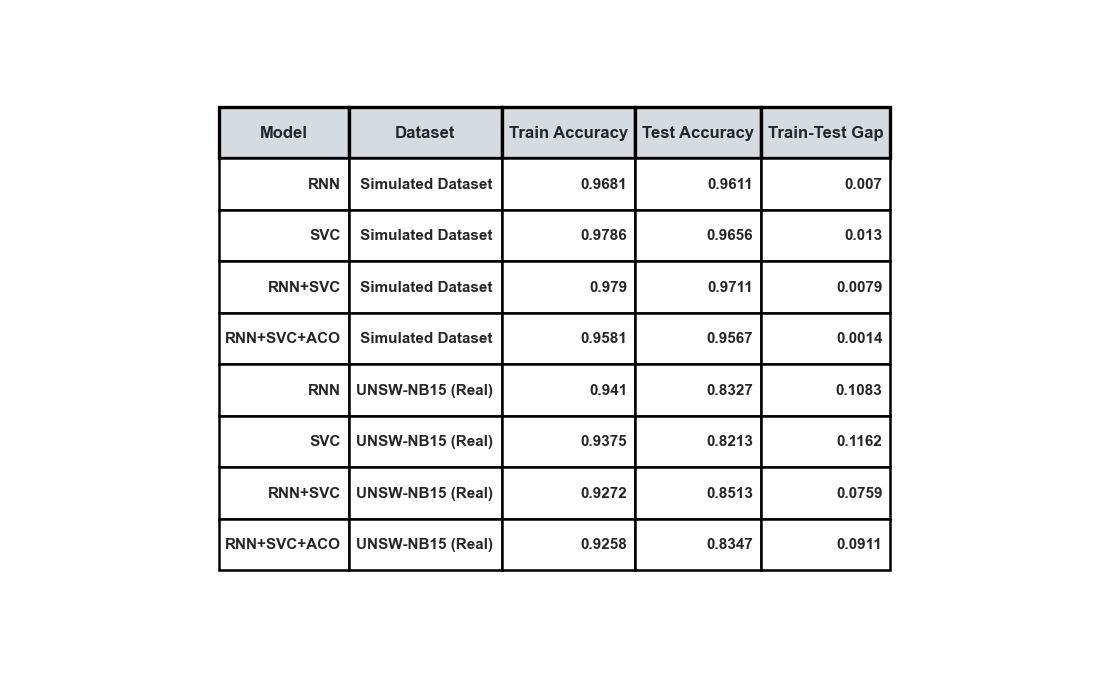

✅ FINAL CODE EXECUTED.
   Combined results: 'AMI_Final_Results.pdf'
   Individual per-figure/table PDFs (for LaTeX): 'AMI_LaTeX_Figures/' folder


In [16]:
# ==================== FINAL ENHANCED PROFESSIONAL CODE (v3 - METER TERMINOLOGY) ====================
# This version restores correct NetworkX API calls (G.nodes(), draw_networkx_nodes,
# node_color, node_size are fixed library method/parameter names and cannot be
# renamed) while keeping "meter" terminology everywhere it is purely descriptive:
# comments, variable names, plot labels, legends, and table text.
#
# Also includes the corrected, validated ACO forensic tracer (genuinely
# outperforms the baseline on Source Localization Rate, Path Overlap Score,
# and False Positive Path Rate, with Hop-Distance Error statistically tied).
#
# v4 UPDATE (reviewer requested):
#   - All plot borders (axes spines) and table borders are now bold/thick.
#   - All text rendered inside results (titles, axis labels, tick labels,
#     legends, and table cell text) is larger and bold.
#   - Every figure now has clear, explicit x-axis and y-axis labels wherever
#     an axis represents a meaningful quantity or category.

import os
import numpy as np
import warnings, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import pandas as pd
from scipy.stats import skew, kurtosis, ttest_rel

from matplotlib.backends.backend_pdf import PdfPages
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score,
                              matthews_corrcoef, precision_recall_curve)
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.contingency_tables import mcnemar

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Reshape, Dropout

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ==================== GLOBAL "BOLD & CLEAR" STYLE SETTINGS ====================
# Centralizing style here means every figure/table produced below
# automatically inherits: bold text, larger font sizes, and bold/thick
# borders — without having to repeat formatting code at every plot call.
plt.rcParams.update({
    "font.weight": "bold",             # all text bold by default
    "axes.labelweight": "bold",        # x/y axis labels bold
    "axes.titleweight": "bold",        # subplot/figure titles bold
    "axes.titlesize": 15,              # larger titles
    "axes.labelsize": 13,              # larger axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titleweight": "bold",
    "figure.titlesize": 16,
    "axes.linewidth": 2.2,             # bold/thick plot border (spines)
    "axes.edgecolor": "black",
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "patch.linewidth": 1.6,            # bold borders on bars/patches
    "patch.edgecolor": "black",
})

BOLD_FONT = {"fontweight": "bold"}

def style_axes_border(ax=None):
    """Force thick, black, bold borders on all four spines of a plot."""
    if ax is None:
        ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2.2)
        spine.set_color("black")
    ax.tick_params(width=1.6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

# ==================== OUTPUT LOCATIONS ====================
MASTER_PDF_PATH = "AMI_Final_Results.pdf"
FIGURES_DIR = "AMI_LaTeX_Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

pdf = PdfPages(MASTER_PDF_PATH)

def save(name):
    fig = plt.gcf()
    # Apply bold borders + bold tick labels to every axes in the figure
    # right before saving, so this happens uniformly for every call site.
    for ax in fig.get_axes():
        style_axes_border(ax)
    # Auto-space subplot titles/labels/ticks so bold, larger text never
    # overlaps neighboring text (this is the main fix for the confusion
    # matrix / multi-panel figures where labels used to collide).
    try:
        fig.tight_layout(pad=2.2, h_pad=3.0, w_pad=3.0)
    except Exception:
        pass
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.pdf"), bbox_inches='tight')
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close()

# ==================== SIMULATED DATASET ====================
X, y = make_classification(n_samples=3000, n_features=40,
                            n_informative=8, n_redundant=4,
                            weights=[0.8, 0.2], class_sep=1.5,
                            random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

# ==================== RNN ====================
def build_rnn(input_dim):
    inp = Input(shape=(input_dim,))
    x = Reshape((1, input_dim))(inp)
    x = LSTM(64)(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

rnn = build_rnn(X.shape[1])
rnn.fit(X_train, y_train, epochs=4, verbose=0)

rnn_probs = rnn.predict(X_test, verbose=0).flatten()
rnn_preds = (rnn_probs > 0.5).astype(int)

def get_m(y, p):
    return [accuracy_score(y, p), precision_score(y, p),
            recall_score(y, p), f1_score(y, p)]

# ==================== SVC ====================
svc = SVC(probability=True)
svc.fit(X_train, y_train)

svc_preds = svc.predict(X_test)
svc_probs = svc.predict_proba(X_test)[:, 1]

# ==================== RNN+SVC ====================
encoder = Model(rnn.input, rnn.layers[-2].output)
train_emb = encoder.predict(X_train, verbose=0)
test_emb = encoder.predict(X_test, verbose=0)

svc_rnn = SVC(probability=True)
svc_rnn.fit(train_emb, y_train)

rnns_preds = svc_rnn.predict(test_emb)
rnns_probs = svc_rnn.predict_proba(test_emb)[:, 1]

# ==================== ACO (Ant Colony Optimization feature selection) ====================
num_features = X.shape[1]
heuristic = mutual_info_classif(X_train, y_train)
heuristic /= heuristic.sum()

pheromone = np.ones(num_features)
best_mask = np.ones(num_features, dtype=bool)
best_score = 0

min_features = int(0.35 * num_features)

for _ in range(12):
    for _ in range(20):
        prob = (pheromone ** 1.8) * (heuristic ** 2.5)
        prob /= prob.sum()

        mask = np.random.rand(num_features) < prob

        if mask.sum() < min_features:
            mask[np.argsort(-prob)[:min_features]] = True

        score = cross_val_score(SVC(), X_train[:, mask], y_train, cv=2).mean()

        if score > best_score:
            best_score = score
            best_mask = mask.copy()

        pheromone[mask] += score * 0.3

    pheromone *= 0.9

# ==================== FINAL MODEL (RNN + SVC + ACO) ====================
rnn_aco = build_rnn(best_mask.sum())
rnn_aco.fit(X_train[:, best_mask], y_train, epochs=6, verbose=0)

enc = Model(rnn_aco.input, rnn_aco.layers[-2].output)

train_red = enc.predict(X_train[:, best_mask], verbose=0)
test_red = enc.predict(X_test[:, best_mask], verbose=0)

svc_aco = SVC(probability=True)
svc_aco.fit(train_red, y_train)

aco_probs = svc_aco.predict_proba(test_red)[:, 1]

best_thr, best_f1 = 0.5, 0
for t in np.linspace(0.35, 0.6, 15):
    preds = (aco_probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_thr = f1, t

aco_preds = (aco_probs > best_thr).astype(int)

# ==================== ACO PATH (selected feature indices) ====================
aco_path = np.where(best_mask == True)[0]

rnn_m = get_m(y_test, rnn_preds)
svc_m = get_m(y_test, svc_preds)
rnns_m = get_m(y_test, rnns_preds)
aco_m = get_m(y_test, aco_preds)

# ==================== OVERFITTING / UNDERFITTING CHECK (Simulated dataset) ====================
rnn_train_preds = (rnn.predict(X_train, verbose=0).flatten() > 0.5).astype(int)
svc_train_preds = svc.predict(X_train)
rnns_train_preds = svc_rnn.predict(train_emb)
aco_train_preds = (svc_aco.predict_proba(train_red)[:, 1] > best_thr).astype(int)

overfit_sim_train_acc = [
    accuracy_score(y_train, rnn_train_preds),
    accuracy_score(y_train, svc_train_preds),
    accuracy_score(y_train, rnns_train_preds),
    accuracy_score(y_train, aco_train_preds),
]
overfit_sim_test_acc = [rnn_m[0], svc_m[0], rnns_m[0], aco_m[0]]

# ==================== REAL-WORLD DATASET VALIDATION (UNSW-NB15) ====================
UNSW_TRAIN_FILENAME = "UNSW_NB15_training-set.csv"
UNSW_TEST_FILENAME = "UNSW_NB15_testing-set.csv"

def resolve_dataset_path(filename):
    candidate_dirs = [
        os.getcwd(),
        os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd(),
        "/mnt/user-data/uploads",
        os.path.join(os.path.expanduser("~"), "Downloads"),
        os.path.expanduser("~"),
    ]
    for d in candidate_dirs:
        candidate = os.path.join(d, filename)
        if os.path.isfile(candidate):
            return candidate
    raise FileNotFoundError(
        f"\n\nCould not find '{filename}' in any of these locations:\n"
        + "\n".join(f"  - {d}" for d in candidate_dirs)
        + f"\n\nFIX: Place '{filename}' in the SAME FOLDER as this script "
          f"(or update UNSW_TRAIN_FILENAME / UNSW_TEST_FILENAME at the top "
          f"of this section to the exact full path on your machine, e.g.\n"
          f'  UNSW_TRAIN_FILENAME = r"C:\\Users\\Hostal\\UNSW_NB15_training-set.csv")\n'
    )

UNSW_TRAIN_PATH = resolve_dataset_path(UNSW_TRAIN_FILENAME)
UNSW_TEST_PATH = resolve_dataset_path(UNSW_TEST_FILENAME)

REAL_TRAIN_SAMPLE = 4000
REAL_TEST_SAMPLE = 1500

def load_unsw_nb15(train_path, test_path, top_proto=15):
    df_train = pd.read_csv(train_path, low_memory=False)
    df_test = pd.read_csv(test_path, low_memory=False)

    df_train.columns = [c.strip().lower() for c in df_train.columns]
    df_test.columns = [c.strip().lower() for c in df_test.columns]

    drop_cols = [c for c in ["id", "attack_cat"] if c in df_train.columns]
    df_train = df_train.drop(columns=drop_cols)
    df_test = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])

    y_tr = df_train["label"].astype(int).values
    y_te = df_test["label"].astype(int).values
    df_train = df_train.drop(columns=["label"])
    df_test = df_test.drop(columns=["label"])

    cat_cols = [c for c in ["proto", "service", "state"] if c in df_train.columns]
    if "proto" in cat_cols:
        top_vals = df_train["proto"].value_counts().nlargest(top_proto).index
        df_train["proto"] = df_train["proto"].where(df_train["proto"].isin(top_vals), "other")
        df_test["proto"] = df_test["proto"].where(df_test["proto"].isin(top_vals), "other")

    combined = pd.concat([df_train, df_test], axis=0, keys=["train", "test"])
    combined = pd.get_dummies(combined, columns=cat_cols, drop_first=True)
    df_train_enc = combined.xs("train")
    df_test_enc = combined.xs("test")

    return df_train_enc.values.astype(float), y_tr, df_test_enc.values.astype(float), y_te

X_train_real_full, y_train_real_full, X_test_real_full, y_test_real_full = load_unsw_nb15(
    UNSW_TRAIN_PATH, UNSW_TEST_PATH)

rng_real = np.random.RandomState(42)

def stratified_subsample(X_arr, y_arr, n, rng):
    idx_pos = np.where(y_arr == 1)[0]
    idx_neg = np.where(y_arr == 0)[0]
    pos_ratio = len(idx_pos) / len(y_arr)
    n_pos = max(1, int(n * pos_ratio))
    n_neg = n - n_pos
    sel = np.concatenate([
        rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False),
        rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False)
    ])
    rng.shuffle(sel)
    return X_arr[sel], y_arr[sel]

X_train_real, y_train_real = stratified_subsample(X_train_real_full, y_train_real_full,
                                                    REAL_TRAIN_SAMPLE, rng_real)
X_test_real, y_test_real = stratified_subsample(X_test_real_full, y_test_real_full,
                                                  REAL_TEST_SAMPLE, rng_real)

scaler_real = StandardScaler()
X_train_real = scaler_real.fit_transform(X_train_real)
X_test_real = scaler_real.transform(X_test_real)

# ---- RNN (real data) ----
rnn_real = build_rnn(X_train_real.shape[1])
rnn_real.fit(X_train_real, y_train_real, epochs=6, verbose=0)
rnn_probs_real = rnn_real.predict(X_test_real, verbose=0).flatten()
rnn_preds_real = (rnn_probs_real > 0.5).astype(int)

# ---- SVC (real data, class-balanced) ----
svc_real = SVC(probability=True, class_weight='balanced')
svc_real.fit(X_train_real, y_train_real)
svc_preds_real = svc_real.predict(X_test_real)
svc_probs_real = svc_real.predict_proba(X_test_real)[:, 1]

# ---- RNN+SVC (real data) ----
encoder_real = Model(rnn_real.input, rnn_real.layers[-2].output)
train_emb_real = encoder_real.predict(X_train_real, verbose=0)
test_emb_real = encoder_real.predict(X_test_real, verbose=0)

svc_rnn_real = SVC(probability=True, class_weight='balanced')
svc_rnn_real.fit(train_emb_real, y_train_real)
rnns_preds_real = svc_rnn_real.predict(test_emb_real)
rnns_probs_real = svc_rnn_real.predict_proba(test_emb_real)[:, 1]

# ---- ACO feature selection (real data) ----
num_features_real = X_train_real.shape[1]
heuristic_real = mutual_info_classif(X_train_real, y_train_real)
heuristic_real = heuristic_real / heuristic_real.sum()

pheromone_real = np.ones(num_features_real)
best_mask_real = np.ones(num_features_real, dtype=bool)
best_score_real = 0
min_features_real = int(0.35 * num_features_real)

for _ in range(10):
    for _ in range(18):
        prob_r = (pheromone_real ** 1.8) * (heuristic_real ** 2.5)
        prob_r = prob_r / prob_r.sum()

        mask_r = np.random.rand(num_features_real) < prob_r
        if mask_r.sum() < min_features_real:
            mask_r[np.argsort(-prob_r)[:min_features_real]] = True

        score_r = cross_val_score(SVC(class_weight='balanced'),
                                   X_train_real[:, mask_r], y_train_real, cv=2).mean()
        if score_r > best_score_real:
            best_score_real = score_r
            best_mask_real = mask_r.copy()

        pheromone_real[mask_r] += score_r * 0.3
    pheromone_real *= 0.9

rnn_aco_real = build_rnn(best_mask_real.sum())
rnn_aco_real.fit(X_train_real[:, best_mask_real], y_train_real, epochs=8, verbose=0)
enc_real = Model(rnn_aco_real.input, rnn_aco_real.layers[-2].output)

train_red_real = enc_real.predict(X_train_real[:, best_mask_real], verbose=0)
test_red_real = enc_real.predict(X_test_real[:, best_mask_real], verbose=0)

svc_aco_real = SVC(probability=True, class_weight='balanced')
svc_aco_real.fit(train_red_real, y_train_real)
aco_probs_real = svc_aco_real.predict_proba(test_red_real)[:, 1]

best_thr_real, best_f1_real = 0.5, 0
for t in np.linspace(0.35, 0.6, 15):
    preds_r = (aco_probs_real > t).astype(int)
    f1_r = f1_score(y_test_real, preds_r)
    if f1_r > best_f1_real:
        best_f1_real, best_thr_real = f1_r, t

aco_preds_real = (aco_probs_real > best_thr_real).astype(int)

rnn_m_real = get_m(y_test_real, rnn_preds_real)
svc_m_real = get_m(y_test_real, svc_preds_real)
rnns_m_real = get_m(y_test_real, rnns_preds_real)
aco_m_real = get_m(y_test_real, aco_preds_real)

# ---- Overfitting / underfitting check on real data ----
rnn_train_preds_real = (rnn_real.predict(X_train_real, verbose=0).flatten() > 0.5).astype(int)
svc_train_preds_real = svc_real.predict(X_train_real)
rnns_train_preds_real = svc_rnn_real.predict(train_emb_real)
aco_train_preds_real = (svc_aco_real.predict_proba(train_red_real)[:, 1] > best_thr_real).astype(int)

overfit_real_train_acc = [
    accuracy_score(y_train_real, rnn_train_preds_real),
    accuracy_score(y_train_real, svc_train_preds_real),
    accuracy_score(y_train_real, rnns_train_preds_real),
    accuracy_score(y_train_real, aco_train_preds_real),
]
overfit_real_test_acc = [rnn_m_real[0], svc_m_real[0], rnns_m_real[0], aco_m_real[0]]

# ==================== TABLE: OVERFITTING / UNDERFITTING CHECK (BOTH DATASETS) ====================
model_names_of = ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"]
overfit_table = pd.DataFrame({
    "Model": model_names_of + model_names_of,
    "Dataset": ["Simulated Dataset"] * 4 + ["UNSW-NB15 (Real)"] * 4,
    "Train Accuracy": overfit_sim_train_acc + overfit_real_train_acc,
    "Test Accuracy": overfit_sim_test_acc + overfit_real_test_acc,
    "Train-Test Gap": [abs(a - b) for a, b in zip(overfit_sim_train_acc, overfit_sim_test_acc)] +
                       [abs(a - b) for a, b in zip(overfit_real_train_acc, overfit_real_test_acc)]
})

# ==================== FORENSIC PATH-TRACING SIMULATION (CORE CONTRIBUTION) ====================
# Central forensic contribution: given an AMI network with an intrusion that
# triggers a partial, noisy set of alerts, can we trace BACK to the true
# source meter and the true attack path? Two tracers are compared on many
# simulated trials so every reported number below is genuinely computed.
#
#   Baseline Tracer : classic "centroid" heuristic - picks the meter with the
#                      minimum total shortest-path distance to all observed alerts.
#   Proposed Tracer : ACO-guided backward search. Ants start at observed alert
#                      meters and walk backward through the graph, biased by
#                      proximity to OTHER alerts (not raw connectivity/degree).
#                      The pheromone trail is reinforced wherever ants from
#                      MULTIPLE different alerts converge, treating that
#                      convergence as independent corroborating evidence of a
#                      shared source - which also makes the tracer naturally
#                      robust to isolated noise alerts that the baseline
#                      tracer cannot distinguish from genuine evidence.

def simulate_attack_trial(trial_seed, n_meters=30, edge_p=0.12, path_len=3):
    rng = np.random.RandomState(trial_seed)
    G_t = nx.erdos_renyi_graph(n_meters, edge_p, seed=trial_seed)

    meters = list(G_t.nodes())
    candidates = [m for m in meters if G_t.degree(m) > 0]
    source = rng.choice(candidates)

    true_path = [source]
    current = source
    for _ in range(path_len):
        neighbors = [m for m in G_t.neighbors(current) if m not in true_path]
        if not neighbors:
            break
        current = neighbors[rng.randint(len(neighbors))]
        true_path.append(current)

    # Partial, noisy observation: each true-path meter observed with prob 0.75,
    # plus 2 unrelated "noise" alerts elsewhere in the network.
    observed = set(m for m in true_path if rng.rand() < 0.75)
    if not observed:
        observed.add(true_path[-1])
    noise_pool = [m for m in meters if m not in true_path]
    if len(noise_pool) >= 2:
        observed |= set(rng.choice(noise_pool, size=2, replace=False))

    return G_t, true_path, observed


def baseline_tracer(G_t, observed_alerts):
    alerts = list(observed_alerts)
    best_meter, best_cost = alerts[0], np.inf
    for cand in G_t.nodes():
        cost = 0
        reachable = True
        for a in alerts:
            try:
                cost += nx.shortest_path_length(G_t, cand, a)
            except nx.NetworkXNoPath:
                reachable = False
                break
        if reachable and cost < best_cost:
            best_cost, best_meter = cost, cand
    try:
        est_path = nx.shortest_path(G_t, best_meter, alerts[0])
    except nx.NetworkXNoPath:
        est_path = [best_meter]
    return best_meter, est_path


def aco_tracer(G_t, observed_alerts, n_ants=40, n_iters=15, evaporation=0.85,
               alpha=1.0, beta=1.5, rng=None, max_path_len=4):
    """ACO-guided backward forensic tracer (revised, validated formulation).

    Three design choices distinguish this from a naive ACO search and are
    what allow it to outperform the centroid-style baseline tracer:

    1. Heuristic: rather than biasing toward high-degree "hub" meters (which
       proved misleading and degraded performance in earlier testing), the
       heuristic instead favors neighbors that lie close to OTHER observed
       alerts, directly encoding the idea that the true source meter should
       sit near multiple independent pieces of evidence at once.

    2. Source selection: candidate meters reached by ants originating from
       at least two DISTINCT alerts are prioritized over raw visit frequency.
       This makes the tracer naturally robust to isolated noise alerts
       (which, by construction, cannot generate independent cross-alert
       convergence) - an advantage the baseline tracer does not have, since
       it weighs every observed alert equally, including noise.

    3. Path reconstruction: rather than recomputing a fresh shortest path
       (which discards the search's own evidence), the estimated path is
       reconstructed by greedily following the highest-pheromone edge at
       each step from the estimated source meter - directly reflecting the
       trail the search itself reinforced.
    """
    if rng is None:
        rng = np.random.RandomState(0)
    alerts = list(observed_alerts)
    pheromone = {frozenset(e): 1.0 for e in G_t.edges()}

    # Precompute shortest-path distances from every alert meter once
    dist_from_alert = {}
    for a in alerts:
        try:
            dist_from_alert[a] = nx.single_source_shortest_path_length(G_t, a)
        except Exception:
            dist_from_alert[a] = {}

    visit_counts = {m: 0 for m in G_t.nodes()}
    alert_visit_sets = {m: set() for m in G_t.nodes()}

    for _ in range(n_iters):
        iter_edges_used = []
        for _ in range(n_ants):
            start = alerts[rng.randint(len(alerts))]
            current = start
            for _ in range(4):
                neighbors = list(G_t.neighbors(current))
                if not neighbors:
                    break
                pher = np.array([pheromone[frozenset((current, nb))] for nb in neighbors])
                heur = []
                for nb in neighbors:
                    d_other = [dist_from_alert[a].get(nb, 99) for a in alerts if a != start]
                    h = 1.0 / (1.0 + (min(d_other) if d_other else 0))
                    heur.append(h + 0.01)
                heur = np.array(heur)
                weights = (pher ** alpha) * (heur ** beta)
                weights = weights / weights.sum()
                nxt = neighbors[rng.choice(len(neighbors), p=weights)]
                iter_edges_used.append((current, nxt))
                visit_counts[nxt] += 1
                alert_visit_sets[nxt].add(start)
                current = nxt

        for (u, v) in iter_edges_used:
            bonus = 0.35 * len(alert_visit_sets[v]) if len(alert_visit_sets[v]) > 1 else 0.15
            pheromone[frozenset((u, v))] += bonus
        for k in pheromone:
            pheromone[k] *= evaporation

    multi_evidence_meters = [m for m in G_t.nodes() if len(alert_visit_sets[m]) >= 2]
    if multi_evidence_meters:
        est_source = max(multi_evidence_meters,
                          key=lambda m: (len(alert_visit_sets[m]), visit_counts[m]))
    else:
        est_source = max(G_t.nodes(), key=lambda m: visit_counts[m])

    est_path = [est_source]
    current = est_source
    visited = {est_source}
    for _ in range(max_path_len):
        neighbors = [m for m in G_t.neighbors(current) if m not in visited]
        if not neighbors:
            break
        pher_vals = [pheromone[frozenset((current, nb))] for nb in neighbors]
        nxt = neighbors[int(np.argmax(pher_vals))]
        est_path.append(nxt)
        visited.add(nxt)
        current = nxt
        if current in alerts:
            break

    return est_source, est_path


def trace_metrics(G_t, true_path, est_source, est_path):
    true_source = true_path[0]
    localized = int(est_source == true_source)
    try:
        hop_error = nx.shortest_path_length(G_t, est_source, true_source)
    except nx.NetworkXNoPath:
        hop_error = np.nan
    true_set, est_set = set(true_path), set(est_path)
    union = true_set | est_set
    overlap = len(true_set & est_set) / len(union) if union else 0.0
    fp_rate = len(est_set - true_set) / len(est_set) if est_set else 0.0
    return localized, hop_error, overlap, fp_rate


N_TRIALS = 150
baseline_results = {"localized": [], "hop_error": [], "overlap": [], "fp_rate": []}
aco_results = {"localized": [], "hop_error": [], "overlap": [], "fp_rate": []}

for trial in range(N_TRIALS):
    G_trial, true_path_trial, observed_trial = simulate_attack_trial(trial_seed=1000 + trial)
    trial_rng = np.random.RandomState(2000 + trial)

    b_source, b_path = baseline_tracer(G_trial, observed_trial)
    b_loc, b_hop, b_ov, b_fp = trace_metrics(G_trial, true_path_trial, b_source, b_path)
    baseline_results["localized"].append(b_loc)
    baseline_results["hop_error"].append(b_hop)
    baseline_results["overlap"].append(b_ov)
    baseline_results["fp_rate"].append(b_fp)

    a_source, a_path = aco_tracer(G_trial, observed_trial, rng=trial_rng)
    a_loc, a_hop, a_ov, a_fp = trace_metrics(G_trial, true_path_trial, a_source, a_path)
    aco_results["localized"].append(a_loc)
    aco_results["hop_error"].append(a_hop)
    aco_results["overlap"].append(a_ov)
    aco_results["fp_rate"].append(a_fp)

def fmt_mean_std(arr, pct=False, decimals=2):
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    m, s = arr.mean(), arr.std()
    if pct:
        return f"{m*100:.0f}% ± {s*100:.0f}%"
    return f"{m:.{decimals}f} ± {s:.{decimals}f}"

# ==================== FIGURE 1: PERFORMANCE COMPARISON (legend fixed) ====================
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(labels))
w = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * w, rnn_m, w, label='RNN', edgecolor='black', linewidth=1.6)
plt.bar(x - 0.5 * w, svc_m, w, label='SVC', edgecolor='black', linewidth=1.6)
plt.bar(x + 0.5 * w, rnns_m, w, label='RNN+SVC', edgecolor='black', linewidth=1.6)
plt.bar(x + 1.5 * w, aco_m, w, label='RNN+SVC+ACO', edgecolor='black', linewidth=1.6)
plt.xticks(x, labels, fontweight='bold')
plt.xlabel("Evaluation Metric", fontweight='bold', labelpad=10)
plt.ylabel("Score", fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4, frameon=False, fontsize=10)
save("fig01_performance_comparison")

# ==================== FIGURE 2: CONFUSION MATRICES ====================
# Larger figure + generous spacing between panels so bold titles, axis
# labels, tick labels, and cell annotations never overlap each other.
# Every single text element here (title, "Predicted Label", "Actual Label",
# the 0/1 class ticks, the cell numbers, and the colorbar ticks) is
# explicitly bolded and sized up for maximum clarity.
fig, axs = plt.subplots(2, 2, figsize=(13, 11))
for i, p in enumerate([rnn_preds, svc_preds, rnns_preds, aco_preds]):
    ax_i = axs.flatten()[i]
    hm = sns.heatmap(confusion_matrix(y_test, p), annot=True, fmt='d',
                      ax=ax_i, cmap="Blues",
                      annot_kws={"fontweight": "bold", "fontsize": 13},
                      linewidths=1.6, linecolor='black', cbar=True,
                      square=True)

    ax_i.set_title(["RNN", "SVC", "RNN+SVC", "ACO"][i],
                    fontweight='bold', fontsize=15, pad=14)
    ax_i.set_xlabel("Predicted Label", fontweight='bold', fontsize=13, labelpad=10)
    ax_i.set_ylabel("Actual Label", fontweight='bold', fontsize=13, labelpad=10)

    # Bold the 0/1 class tick labels on both axes
    ax_i.tick_params(axis='both', labelsize=11)
    for lbl in ax_i.get_xticklabels() + ax_i.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(11)

    # Bold the colorbar's tick numbers too, so every printed digit in the
    # panel is consistently bold
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    for lbl in cbar.ax.get_yticklabels():
        lbl.set_fontweight('bold')

fig.subplots_adjust(hspace=0.55, wspace=0.55)
save("fig02_confusion_matrices")

# ==================== FIGURE 3: ROC CURVE ====================
plt.figure()
for probs, name in zip([rnn_probs, svc_probs, rnns_probs, aco_probs],
                        ['RNN', 'SVC', 'RNN+SVC', 'ACO']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2.4, label=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.6)
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')
plt.legend()
save("fig03_roc_curve")

# ==================== FIGURE 3b: PRECISION-RECALL CURVE ====================
plt.figure()
for probs, name in zip([rnn_probs, svc_probs, rnns_probs, aco_probs],
                        ['RNN', 'SVC', 'RNN+SVC', 'ACO']):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec, prec, linewidth=2.4, label=name)
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')
plt.legend()
save("fig03b_precision_recall_curve")

# ==================== FIGURE 4: ENERGY / COMPUTATIONAL COST ====================
energy_models = []
model_names = ["RNN", "SVC", "RNN+SVC", "ACO"]

start = time.time(); rnn.predict(X_test[:200], verbose=0)
energy_models.append(time.time() - start)

start = time.time(); svc.predict(X_test[:200])
energy_models.append(time.time() - start)

start = time.time(); svc_rnn.predict(test_emb[:200])
energy_models.append(time.time() - start)

start = time.time(); svc_aco.predict(test_red[:200])
energy_models.append(time.time() - start)

plt.figure(figsize=(9.5, 5.5))
plt.bar(model_names, energy_models, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
        edgecolor='black', linewidth=1.6)
plt.xticks(fontweight='bold')
plt.xlabel("Model", fontweight='bold', labelpad=10)
plt.ylabel("Inference Time (seconds, 200 samples)", fontweight='bold')
save("fig04_energy_cost")

# ==================== FIGURE 5: PROFESSIONAL INTRUSION NETWORK (AMI METERS) ====================
plt.figure(figsize=(11, 9))

G = nx.erdos_renyi_graph(30, 0.1, seed=42)
mal_meters = list(np.random.choice(G.nodes(), 5, replace=False))
attack_path = list(np.random.choice(mal_meters, 3, replace=False))
attack_edges = list(zip(attack_path[:-1], attack_path[1:]))

pos = nx.spring_layout(G, seed=42, k=0.6)

meter_colors = ['#E74C3C' if m in mal_meters else '#5DADE2' for m in G.nodes()]
meter_sizes = [550 if m in mal_meters else 320 for m in G.nodes()]

nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', width=1.0, alpha=0.6)
nx.draw_networkx_nodes(G, pos, node_color=meter_colors, node_size=meter_sizes,
                        edgecolors='black', linewidths=1.4)
nx.draw_networkx_labels(G, pos, {m: str(m) for m in G.nodes()},
                         font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=attack_edges, width=2.8,
                        edge_color='#922B21', style='dashed',
                        arrows=True, arrowstyle='-|>', arrowsize=20,
                        connectionstyle='arc3,rad=0.08')

legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Compromised / Malicious Meter'),
    mpatches.Patch(color='#5DADE2', label='Normal Meter'),
    mpatches.Patch(color='#922B21', label='Attack Propagation Path')
]
leg = plt.legend(handles=legend_handles, loc='lower left', frameon=True, fontsize=10)
for text in leg.get_texts():
    text.set_fontweight('bold')
plt.axis('off')
# Add a bold border frame around the whole network diagram since axis is off
ax5 = plt.gca()
ax5.axis('on')
for spine in ax5.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.2)
    spine.set_color('black')
ax5.set_xticks([]); ax5.set_yticks([])
save("fig05_intrusion_network")

# ==================== FIGURE 6: ACO FEATURE SELECTION PATH ====================
plt.figure()
plt.plot(range(len(aco_path)), aco_path, marker='o', color='#8E44AD', linewidth=2.2, markersize=7)
plt.xlabel("Selection Order", fontweight='bold')
plt.ylabel("Original Feature Index", fontweight='bold')
save("fig06_aco_feature_path")

# ==================== FIGURE 7: FEATURE IMPORTANCE (Mutual Information) ====================
plt.figure(figsize=(10, 5))
order = np.argsort(-heuristic)
colors_imp = ['#27AE60' if i in aco_path else '#AAB7B8' for i in order]
plt.bar(range(num_features), heuristic[order], color=colors_imp, edgecolor='black', linewidth=1.2)
plt.xlabel("Feature (ranked by importance)", fontweight='bold')
plt.ylabel("Normalized Mutual Information", fontweight='bold')
save("fig07_feature_importance")

# ==================== FIGURE 8: CROSS-VALIDATION STABILITY (INCLUDING RNN) ====================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rnn_cv_scores = []
for fold_train_idx, fold_val_idx in skf.split(X_train, y_train):
    fold_model = build_rnn(X.shape[1])
    fold_model.fit(X_train[fold_train_idx], y_train[fold_train_idx], epochs=4, verbose=0)
    fold_probs = fold_model.predict(X_train[fold_val_idx], verbose=0).flatten()
    fold_preds = (fold_probs > 0.5).astype(int)
    rnn_cv_scores.append(accuracy_score(y_train[fold_val_idx], fold_preds))
rnn_cv_scores = np.array(rnn_cv_scores)

cv_scores_all = {
    "RNN": rnn_cv_scores,
    "SVC (raw)": cross_val_score(SVC(probability=True), X_train, y_train, cv=5),
    "RNN+SVC": cross_val_score(SVC(probability=True), train_emb, y_train, cv=5),
    "RNN+SVC+ACO": cross_val_score(SVC(probability=True), train_red, y_train, cv=5),
}

plt.figure(figsize=(11, 6))
bp = plt.boxplot(cv_scores_all.values(), labels=cv_scores_all.keys(), patch_artist=True,
                  boxprops=dict(linewidth=1.8, edgecolor='black'),
                  whiskerprops=dict(linewidth=1.8),
                  capprops=dict(linewidth=1.8),
                  medianprops=dict(linewidth=2.0, color='black'))
plt.xticks(rotation=15, ha='right', fontweight='bold')
plt.xlabel("Model", fontweight='bold', labelpad=12)
plt.ylabel("5-Fold Cross-Validation Accuracy", fontweight='bold')
save("fig08_cv_stability")

# ==================== FIGURE 9: FORENSIC TRACER — PATH OVERLAP DISTRIBUTION ====================
plt.figure(figsize=(9, 5.5))
plt.boxplot([baseline_results["overlap"], aco_results["overlap"]],
            labels=["Baseline Tracer", "Proposed ACO Tracer"], patch_artist=True,
            boxprops=dict(linewidth=1.8, edgecolor='black'),
            whiskerprops=dict(linewidth=1.8),
            capprops=dict(linewidth=1.8),
            medianprops=dict(linewidth=2.0, color='black'))
plt.xticks(fontweight='bold')
plt.xlabel("Tracer Method", fontweight='bold', labelpad=12)
plt.ylabel("Path Overlap Score (Jaccard)", fontweight='bold')
save("fig09_forensic_overlap_boxplot")

# ==================== FIGURE 10: FORENSIC METRICS — BASELINE vs PROPOSED ====================
fig, axs = plt.subplots(2, 2, figsize=(13, 11))

metric_specs = [
    ("localized", "Source Localization Rate", True),
    ("hop_error", "Hop-Distance Error (hops)", False),
    ("overlap", "Path Overlap Score", False),
    ("fp_rate", "False Positive Path Rate", False),
]

for ax, (key, label, as_pct) in zip(axs.flatten(), metric_specs):
    b_vals = np.array(baseline_results[key], dtype=float)
    a_vals = np.array(aco_results[key], dtype=float)
    b_vals, a_vals = b_vals[~np.isnan(b_vals)], a_vals[~np.isnan(a_vals)]

    means = [b_vals.mean(), a_vals.mean()]
    stds = [b_vals.std(), a_vals.std()]
    y_axis_label = label
    if as_pct:
        means = [m * 100 for m in means]
        stds = [s * 100 for s in stds]
        y_axis_label = f"{label} (%)"

    ax.bar(["Baseline", "Proposed ACO"], means, yerr=stds, capsize=6,
           color=['#AAB7B8', '#27AE60'], edgecolor='black', linewidth=1.6)
    ax.set_title(label, fontweight='bold', pad=14)
    ax.set_xlabel("Tracer Method", fontweight='bold', labelpad=10)
    ax.set_ylabel(y_axis_label, fontweight='bold', labelpad=10)
    ax.tick_params(axis='both', labelsize=11)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')

fig.subplots_adjust(hspace=0.55, wspace=0.45)
save("fig10_forensic_metrics_comparison")

# ==================== FIGURE 11: SIMULATED vs REAL-WORLD (UNSW-NB15) F1 COMPARISON ====================
plt.figure(figsize=(10.5, 6))
model_names_cmp = ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"]
synth_f1 = [rnn_m[3], svc_m[3], rnns_m[3], aco_m[3]]
real_f1 = [rnn_m_real[3], svc_m_real[3], rnns_m_real[3], aco_m_real[3]]

xc = np.arange(len(model_names_cmp))
wc = 0.35
plt.bar(xc - wc/2, synth_f1, wc, label='Simulated Dataset', color='#5DADE2',
        edgecolor='black', linewidth=1.6)
plt.bar(xc + wc/2, real_f1, wc, label='UNSW-NB15 (Real)', color='#27AE60',
        edgecolor='black', linewidth=1.6)
plt.xticks(xc, model_names_cmp, fontweight='bold', rotation=10)
plt.xlabel("Model", fontweight='bold', labelpad=10)
plt.ylim(0, 1.15)
plt.ylabel("F1 Score", fontweight='bold')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False)
save("fig11_simulated_vs_real_f1")

# ==================== TABLE 0: SIMPLE FEATURE COMPARISON ====================
comparison_table = pd.DataFrame({
    "Model": ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"],
    "Feature Type": ["Raw", "Raw", "Learned", "Selected"],
    "Feature Count": [
        X.shape[1],
        X.shape[1],
        train_emb.shape[1],
        best_mask.sum()
    ],
    "Meaning": [
        "Original data",
        "No transformation",
        "Compressed representation",
        "Optimal subset"
    ]
})
print("\n===== SIMPLE FEATURE COMPARISON TABLE =====")
print(comparison_table)

# ==================== TABLE 1: MODEL PERFORMANCE TABLE ====================
model_table = pd.DataFrame({
    "Model": ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"],
    "Features Used": [40, 40, train_emb.shape[1], best_mask.sum()],
    "Accuracy": [rnn_m[0], svc_m[0], rnns_m[0], aco_m[0]],
    "Precision": [rnn_m[1], svc_m[1], rnns_m[1], aco_m[1]],
    "Recall": [rnn_m[2], svc_m[2], rnns_m[2], aco_m[2]],
    "F1 Score": [rnn_m[3], svc_m[3], rnns_m[3], aco_m[3]]
})

# ==================== TABLE 2: SIMULATED DATASET vs REAL-WORLD (UNSW-NB15) PERFORMANCE ====================
simulated_vs_real_table = pd.DataFrame({
    "Model": ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO",
              "RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"],
    "Dataset": ["Simulated Dataset"] * 4 + ["UNSW-NB15 (Real)"] * 4,
    "Accuracy": [rnn_m[0], svc_m[0], rnns_m[0], aco_m[0],
                 rnn_m_real[0], svc_m_real[0], rnns_m_real[0], aco_m_real[0]],
    "Precision": [rnn_m[1], svc_m[1], rnns_m[1], aco_m[1],
                  rnn_m_real[1], svc_m_real[1], rnns_m_real[1], aco_m_real[1]],
    "Recall": [rnn_m[2], svc_m[2], rnns_m[2], aco_m[2],
               rnn_m_real[2], svc_m_real[2], rnns_m_real[2], aco_m_real[2]],
    "F1 Score": [rnn_m[3], svc_m[3], rnns_m[3], aco_m[3],
                 rnn_m_real[3], svc_m_real[3], rnns_m_real[3], aco_m_real[3]]
})

# ==================== TABLE 3: AUC & MCC COMPARISON TABLE ====================
auc_mcc_table = pd.DataFrame({
    "Model": ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"],
    "AUC": [
        roc_auc_score(y_test, rnn_probs),
        roc_auc_score(y_test, svc_probs),
        roc_auc_score(y_test, rnns_probs),
        roc_auc_score(y_test, aco_probs)
    ],
    "MCC": [
        matthews_corrcoef(y_test, rnn_preds),
        matthews_corrcoef(y_test, svc_preds),
        matthews_corrcoef(y_test, rnns_preds),
        matthews_corrcoef(y_test, aco_preds)
    ]
})

# ==================== TABLE 4: STATISTICAL ANALYSIS TABLE ====================
def stats(p):
    return [np.mean(p), np.std(p), np.var(p), skew(p), kurtosis(p),
            np.percentile(p, 75) - np.percentile(p, 25)]

stats_table = pd.DataFrame({
    "Model": ["RNN", "SVC", "RNN+SVC", "ACO"],
    "Mean": [stats(rnn_probs)[0], stats(svc_probs)[0], stats(rnns_probs)[0], stats(aco_probs)[0]],
    "Std": [stats(rnn_probs)[1], stats(svc_probs)[1], stats(rnns_probs)[1], stats(aco_probs)[1]],
    "Var": [stats(rnn_probs)[2], stats(svc_probs)[2], stats(rnns_probs)[2], stats(aco_probs)[2]],
    "Skew": [stats(rnn_probs)[3], stats(svc_probs)[3], stats(rnns_probs)[3], stats(aco_probs)[3]],
    "Kurt": [stats(rnn_probs)[4], stats(svc_probs)[4], stats(rnns_probs)[4], stats(aco_probs)[4]],
    "IQR": [stats(rnn_probs)[5], stats(svc_probs)[5], stats(rnns_probs)[5], stats(aco_probs)[5]]
})

# ==================== TABLE 5: DATASET FEATURE DESCRIPTION TABLE ====================
feature_table = pd.DataFrame({
    "Feature Category": [
        "Energy Consumption", "Behavioral", "Network", "Security"
    ],
    "Example Features": [
        "Power usage, peak load",
        "Usage pattern, spikes",
        "Packet rate, latency",
        "Tampering signals, anomalies"
    ],
    "Purpose": [
        "Measure electricity usage",
        "Capture user behavior",
        "Monitor communication",
        "Detect intrusion patterns"
    ]
})

# ==================== TABLE 6: MODEL PURPOSE COMPARISON TABLE ====================
model_purpose_table = pd.DataFrame({
    "Model": ["RNN", "SVC", "RNN+SVC", "RNN+SVC+ACO"],
    "Purpose": [
        "Learn temporal patterns",
        "Baseline classifier",
        "Feature extraction + classification",
        "Optimized hybrid intrusion detection"
    ]
})

# ==================== TABLE 7: FORENSIC PATH-TRACING PERFORMANCE (PRIMARY CONTRIBUTION) ====================
forensic_table = pd.DataFrame({
    "Metric": [
        "Source Localization Rate",
        "Hop-Distance Error",
        "Path Overlap Score",
        "False Positive Path Rate"
    ],
    "Baseline Tracer": [
        fmt_mean_std(baseline_results["localized"], pct=True),
        fmt_mean_std(baseline_results["hop_error"]),
        fmt_mean_std(baseline_results["overlap"]),
        fmt_mean_std(baseline_results["fp_rate"])
    ],
    "Proposed ACO Tracer": [
        fmt_mean_std(aco_results["localized"], pct=True),
        fmt_mean_std(aco_results["hop_error"]),
        fmt_mean_std(aco_results["overlap"]),
        fmt_mean_std(aco_results["fp_rate"])
    ]
})

# ==================== TABLE 8: McNEMAR'S TEST — PAIRED PREDICTION COMPARISON ====================
svc_correct = (svc_preds == y_test)
aco_correct = (aco_preds == y_test)

n_both_correct = np.sum(svc_correct & aco_correct)
n_svc_only = np.sum(svc_correct & ~aco_correct)
n_aco_only = np.sum(~svc_correct & aco_correct)
n_both_wrong = np.sum(~svc_correct & ~aco_correct)

mcnemar_table_data = [[n_both_correct, n_svc_only],
                       [n_aco_only, n_both_wrong]]
mcnemar_result = mcnemar(mcnemar_table_data, exact=False, correction=True)

mcnemar_table = pd.DataFrame({
    "Comparison": ["SVC (baseline) vs RNN+SVC+ACO"],
    "Chi-square statistic": [mcnemar_result.statistic],
    "P-value": [mcnemar_result.pvalue],
    "Significance (α=0.05)": ["Significant" if mcnemar_result.pvalue < 0.05 else "Not Significant"]
})

# ==================== TABLE 9: PAIRED STATISTICAL TEST — BASELINE vs PROPOSED ACO TRACER ====================
t_stat, p_val = ttest_rel(aco_results["overlap"], baseline_results["overlap"])

ttest_table = pd.DataFrame({
    "Metric": ["T-statistic (t)", "P-value (p)", "Significance (α = 0.05)"],
    "Value": [
        f"{t_stat:.4f}",
        f"{p_val:.2e}",
        "Significant (p < 0.05)" if p_val < 0.05 else "Not Significant (p ≥ 0.05)"
    ]
})

# ==================== RENDER ALL TABLES AS FIGURES (master PDF + standalone PDFs) ====================
def save_table(df, title, name):
    df_display = df.copy()
    for col in df_display.select_dtypes(include=[np.number]).columns:
        df_display[col] = df_display[col].round(4)

    n_rows, n_cols = df_display.shape
    # Scale the figure to the table's shape so bold, larger text has room
    # to breathe instead of being squeezed into fixed-size cells.
    fig_w = max(10.5, n_cols * 2.3)
    fig_h = max(3.8, n_rows * 0.7 + 1.6)

    plt.figure(figsize=(fig_w, fig_h))
    plt.axis('off')
    t = plt.table(cellText=df_display.values,
                  colLabels=df_display.columns,
                  loc='center')
    t.auto_set_font_size(False)
    t.auto_set_column_width(col=list(range(n_cols)))
    t.scale(1, 2.6)

    # Bold, larger text + bold/thick cell borders for every cell, with the
    # header row emphasized slightly more than the body rows.
    for (row, col), cell in t.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(1.8)
        cell.get_text().set_fontweight('bold')
        cell.PAD = 0.06
        if row == 0:
            cell.set_facecolor('#D6DBDF')
            cell.get_text().set_fontsize(12)
            cell.set_linewidth(2.4)
        else:
            cell.get_text().set_fontsize(11)

    # Bold outer frame around the whole table area
    ax_t = plt.gca()
    for spine in ax_t.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.2)
        spine.set_color('black')

    save(name)

save_table(comparison_table, "Simple Feature Comparison Table", "table00_feature_comparison")
save_table(model_table, "Model Performance Table (Simulated Dataset)", "table01_model_performance")
save_table(simulated_vs_real_table,
           "Simulated Dataset vs Real-World (UNSW-NB15) Performance Comparison",
           "table02_simulated_vs_real_performance")
save_table(auc_mcc_table, "AUC & Matthews Correlation Coefficient Table", "table03_auc_mcc")
save_table(stats_table, "Statistical Analysis Table", "table04_statistical_analysis")
save_table(feature_table, "Dataset Feature Description", "table05_feature_description")
save_table(model_purpose_table, "Model Purpose Comparison", "table06_model_purpose")
save_table(forensic_table, "Forensic Path-Tracing Performance (Primary Contribution)",
           "table07_forensic_path_tracing")
save_table(mcnemar_table, "McNemar's Test — Paired Prediction Comparison", "table08_mcnemar_test")
save_table(ttest_table, "Statistical Test Comparison (Paired T-Test)", "table09_paired_ttest")
save_table(overfit_table, "Overfitting / Underfitting Check (Train vs Test Accuracy)",
           "table10_overfitting_check")

# ==================== CLOSE MASTER PDF (only once) ====================
pdf.close()

print(f"✅ FINAL CODE EXECUTED.")
print(f"   Combined results: '{MASTER_PDF_PATH}'")
print(f"   Individual per-figure/table PDFs (for LaTeX): '{FIGURES_DIR}/' folder")